In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/processed/datasets/datasetUsers1.csv")

In [5]:
import pandas as pd
import numpy as np

def hashtag_overlap_matrix(df, hashtag_col="hashtag", user_col="A_id"):
    # Build hashtag -> set of unique users
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    pd.set_option("display.expand_frame_repr", False)
    hashtag_users = (
        df.groupby(hashtag_col)[user_col]
        .apply(lambda x: set(x.unique()))
        .to_dict()
    )
    
    hashtags = sorted(hashtag_users.keys())
    
    # Print unique recipient counts
    print("Pairwise overlap matrix (1:1)")

    # Initialize zero matrix
    n = len(hashtags)
    overlap_matrix = pd.DataFrame(
        np.zeros((n, n), dtype=int),
        index=hashtags,
        columns=hashtags
    )
    
    # Fill diagonal + upper triangle only
    for i, tag1 in enumerate(hashtags):
        users1 = hashtag_users[tag1]
        overlap_matrix.iloc[i, i] = len(users1)  # diagonal
        
        for j in range(i + 1, n):
            tag2 = hashtags[j]
            users2 = hashtag_users[tag2]
            overlap = len(users1 & users2)
            overlap_matrix.iloc[i, j] = overlap
    
    return overlap_matrix
matrix = hashtag_overlap_matrix(df)
print(matrix)

Pairwise overlap matrix (1:1)
                     AI  Anime  BlackHistoryMonth  Booksky  Gaza   ICE  Pokemon  Superbowl  TheTraitors  Trump
AI                 2508     98                117       62   133   192       19         72            8    165
Anime                 0   3816                101       74    21    25      277         43            3     16
BlackHistoryMonth     0      0               5394      216   242   436       81        226           18    333
Booksky               0      0                  0     3655    64   112       39         71           19     90
Gaza                  0      0                  0        0  3234   354       22        103           18    365
ICE                   0      0                  0        0     0  3716       25        207           14    526
Pokemon               0      0                  0        0     0     0     5524         56           12      5
Superbowl             0      0                  0        0     0     0        0   

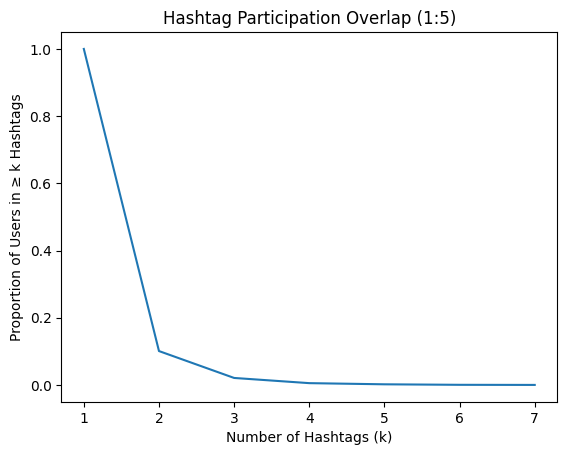

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_hashtag_participation(df, hashtag_col="hashtag", user_col="A_id"):
    
    # Count unique hashtags per user
    user_hashtag_counts = (
        df.groupby(user_col)[hashtag_col]
          .nunique()
    )
    
    total_users = len(user_hashtag_counts)
    max_k = user_hashtag_counts.max()
    
    k_values = list(range(1, max_k + 1))
    proportions = [
        (user_hashtag_counts >= k).sum() / total_users
        for k in k_values
    ]
    
    plt.figure()
    plt.plot(k_values, proportions)
    
    # 👇 Force all integer ticks to show
    plt.xticks(k_values)
    
    plt.xlabel("Number of Hashtags (k)")
    plt.ylabel("Proportion of Users in ≥ k Hashtags")
    plt.title("Hashtag Participation Overlap (1:5)")
    plt.show()


# Run
plot_hashtag_participation(df)

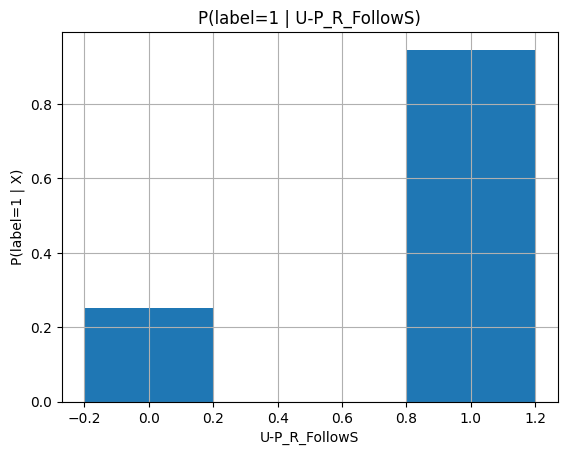

In [9]:
import numpy as np
import matplotlib.pyplot as plt


def plot_p_label_given_x(df, column, bins=50, x_max=None, title=None):
    """
    Plots P(label=1 | X).
    Handles both continuous and binary features.
    """

    x = df[column].values
    y = df["label"].values

    # Optional clipping
    if x_max is not None:
        mask = x <= x_max
        x = x[mask]
        y = y[mask]

    unique_vals = np.unique(x)

    # ------------------------------
    # Binary feature case
    # ------------------------------
    if len(unique_vals) <= 2:

        xs = []
        ps = []

        for val in sorted(unique_vals):
            mask = x == val
            if np.sum(mask) > 0:
                xs.append(val)
                ps.append(np.mean(y[mask]))

        plt.figure()
        plt.bar(xs, ps, width=0.4)

    # ------------------------------
    # Continuous feature case
    # ------------------------------
    else:

        bin_edges = np.linspace(np.min(x), np.max(x), bins + 1)
        bin_indices = np.digitize(x, bin_edges) - 1

        prob = []
        bin_centers = []

        for i in range(bins):
            mask = bin_indices == i
            if np.sum(mask) > 0:
                p = np.mean(y[mask])
                prob.append(p)
                bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)

        plt.figure()
        plt.plot(bin_centers, prob)

    plt.xlabel(column)
    plt.ylabel("P(label=1 | X)")

    if title:
        plt.title(title)
    else:
        plt.title(f"P(label=1 | {column})")

    plt.grid(True)
    plt.show()
plot_p_label_given_x(df, "U-P_R_FollowS")

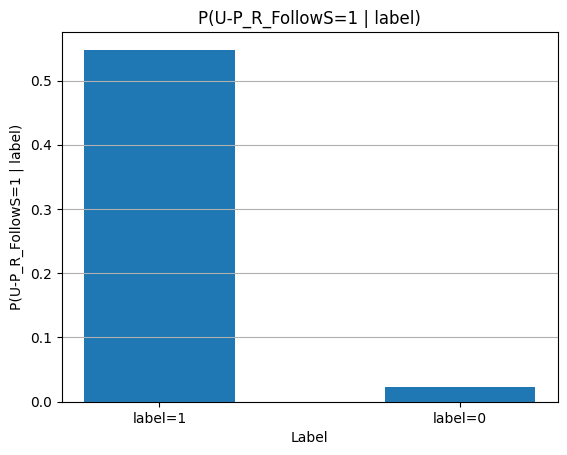

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_p_x_given_label(df, column, title=None):
    """
    Plots P(X=1 | label).
    Assumes the column is binary (0/1).
    """

    x = df[column].values
    y = df["label"].values

    p_x1_given_label1 = np.mean(x[y == 1])
    p_x1_given_label0 = np.mean(x[y == 0])

    xs = ["label=1", "label=0"]
    ps = [p_x1_given_label1, p_x1_given_label0]

    plt.figure()
    plt.bar(xs, ps, width=0.5)

    plt.ylabel(f"P({column}=1 | label )")
    plt.xlabel("Label")

    if title:
        plt.title(title)
    else:
        plt.title(f"P({column}=1 | label )")

    plt.grid(axis="y")
    plt.show()
plot_p_x_given_label(df,"U-P_R_FollowS")